# Posterior for local recombination rate using SBI (real genes)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from Bio import Phylo
import torch
from torch.distributions import Uniform
from sbi.utils.user_input_checks import MultipleIndependent
from sbi.inference import NPE_C
from sbi.analysis import plot_summary
import sys
sys.path.append('../pysimARG')
from clonal_genealogy import ClonalTree
from newick_to_tree import newick_to_tree
from discrete_uniform import DiscreteUniform

torch_device = "cpu"

c:\Users\u2008181\likelihood-free\sbi_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.


## Load simulation data

Load staph gene data and clonal tree.

In [2]:
np.random.seed(100)
clonal_tree = ClonalTree(n=110)

# Load phylo tree and convert to ClonalTree format
phylo_tree = Phylo.read("../data/staph/saureus_clonal.nwk", "newick")
Phylo.draw_ascii(phylo_tree)

edge, node_height = newick_to_tree(phylo_tree)
clonal_tree.edge = edge
clonal_tree.node_height = node_height
clonal_tree.height = np.max(node_height)
clonal_tree.length = np.sum(edge[:, 2])

                                                                   , C1139
                                                                  ,|
                                                                  |, C9658
                                                                  ||
                                                                  |, C1282
                                                                  ||
                      ____________________________________________|, C1280
                     |                                            ||
                     |                                            || C1080
                     |                                            |
                     |                                            |_ C1079
                     |                                            |
                     |                                            , C1147
                     |                                          

In [20]:
x_obs_df = pd.read_csv("../data/staph/core_gene_summary_stats.csv", index_col=0)
x_obs_np = x_obs_df.to_numpy()
x_obs_torch = torch.tensor(x_obs_np, device=torch_device)
x_obs_torch = x_obs_torch.to(torch.float32)
x_obs_torch.shape, x_obs_torch.dtype

(torch.Size([1983, 46]), torch.float32)

## Load simulation data

In [10]:
theta1 = np.loadtxt('../data/staph/ClonalOrigin_sim/theta1.csv', delimiter=",")
x1 = np.loadtxt('../data/staph/ClonalOrigin_sim/x1.csv', delimiter=",")

theta2 = np.loadtxt('../data/staph/ClonalOrigin_sim/theta2.csv', delimiter=",")
x2 = np.loadtxt('../data/staph/ClonalOrigin_sim/x2.csv', delimiter=",")

theta3 = np.loadtxt('../data/staph/ClonalOrigin_sim/theta3.csv', delimiter=",")
x3 = np.loadtxt('../data/staph/ClonalOrigin_sim/x3.csv', delimiter=",")

x = np.vstack([x1, x2, x3])
theta = np.vstack([theta1, theta2, theta3])

print(theta.shape, x.shape)

(50000, 2) (50000, 46)


In [11]:
theta = torch.tensor(theta, device=torch_device)
theta = theta.to(torch.float32)
theta_numpy = theta.cpu().numpy()

x = torch.tensor(x, device=torch_device)
x = x.to(torch.float32)
x_numpy = x.cpu().numpy()

## NPE

### Create prior to pass range knowledge to NPE

In [12]:
prior_rho = Uniform(low=torch.tensor([0.0]), high=torch.tensor([0.1]))
prior_L = DiscreteUniform(low=torch.tensor([20.0]), high=torch.tensor([10000.0]))

prior = MultipleIndependent(
    dists=[prior_rho, prior_L],
    validate_args=False,
    device=torch_device
)

In [13]:
seed = 100
num_posterior_samples=1000
learning_rate = 0.0005

inference = NPE_C(prior=prior, density_estimator="nsf", device=torch_device)
torch.manual_seed(seed)
np.random.seed(seed)

In [14]:
density_estimator = inference.append_simulations(theta, x).train(
    max_num_epochs=500, learning_rate=learning_rate
)
posterior = inference.build_posterior(density_estimator)

 Neural network successfully converged after 148 epochs.

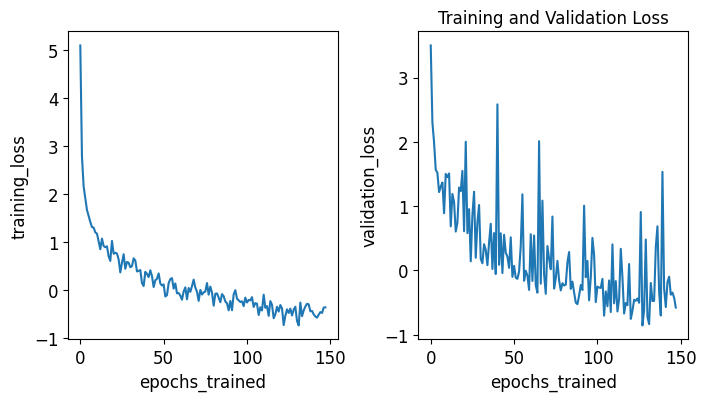

In [15]:
fig, axes = plot_summary(
    inference, 
    tags=["training_loss", "validation_loss"], 
    figsize=(8, 4)
)
plt.title("Training and Validation Loss")
plt.show()

### Plug in observation data to get posterior

In [21]:
theta_post = np.full((x_obs_torch.shape[0], num_posterior_samples, 2), np.nan)
theta_post.shape

(1983, 1000, 2)

In [41]:
ignore_indices = []
for i in range(x_obs_torch.shape[0]):
    ignore_i = False
    for j in range(46):
        max_j = torch.max(x[:, j])
        min_j = torch.min(x[:, j])
        obs_j = x_obs_torch[i, j]
        if obs_j < min_j or obs_j > max_j:
            ignore_i = True
    if ignore_i or torch.isnan(x_obs_torch[i, :]).any():
        print(f"Observation {i} is outside the range of simulated data. Skipping.")
        ignore_indices.append(i)

Observation 5 is outside the range of simulated data. Skipping.
Observation 6 is outside the range of simulated data. Skipping.
Observation 7 is outside the range of simulated data. Skipping.
Observation 8 is outside the range of simulated data. Skipping.
Observation 20 is outside the range of simulated data. Skipping.
Observation 22 is outside the range of simulated data. Skipping.
Observation 27 is outside the range of simulated data. Skipping.
Observation 29 is outside the range of simulated data. Skipping.
Observation 30 is outside the range of simulated data. Skipping.
Observation 31 is outside the range of simulated data. Skipping.
Observation 35 is outside the range of simulated data. Skipping.
Observation 39 is outside the range of simulated data. Skipping.
Observation 47 is outside the range of simulated data. Skipping.
Observation 64 is outside the range of simulated data. Skipping.
Observation 82 is outside the range of simulated data. Skipping.
Observation 85 is outside the

In [42]:
len(ignore_indices)

300

In [51]:
for i in range(100):
    if i in ignore_indices:
        continue
    theta_post_torch = posterior.sample((num_posterior_samples,), x=x_obs_torch[i, :], show_progress_bars=False)
    theta_post[i, :, :] = theta_post_torch.cpu().numpy()

C:\Users\u2008181\AppData\Local\Temp\ipykernel_15032\984743485.py:4: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(theta_post[i, :, 0], color='blue', linewidth=0.3, alpha=0.5)
C:\Users\u2008181\AppData\Local\Temp\ipykernel_15032\984743485.py:4: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(theta_post[i, :, 0], color='blue', linewidth=0.3, alpha=0.5)
C:\Users\u2008181\AppData\Local\Temp\ipykernel_15032\984743485.py:4: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(theta_post[i, :, 0], color='blue', linewidth=0.3, alpha=0.5)
C:\Users\u2008181\AppData\Local\Temp\ipykernel_15032\984743485.py:4: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(theta_post[i, :, 0], 

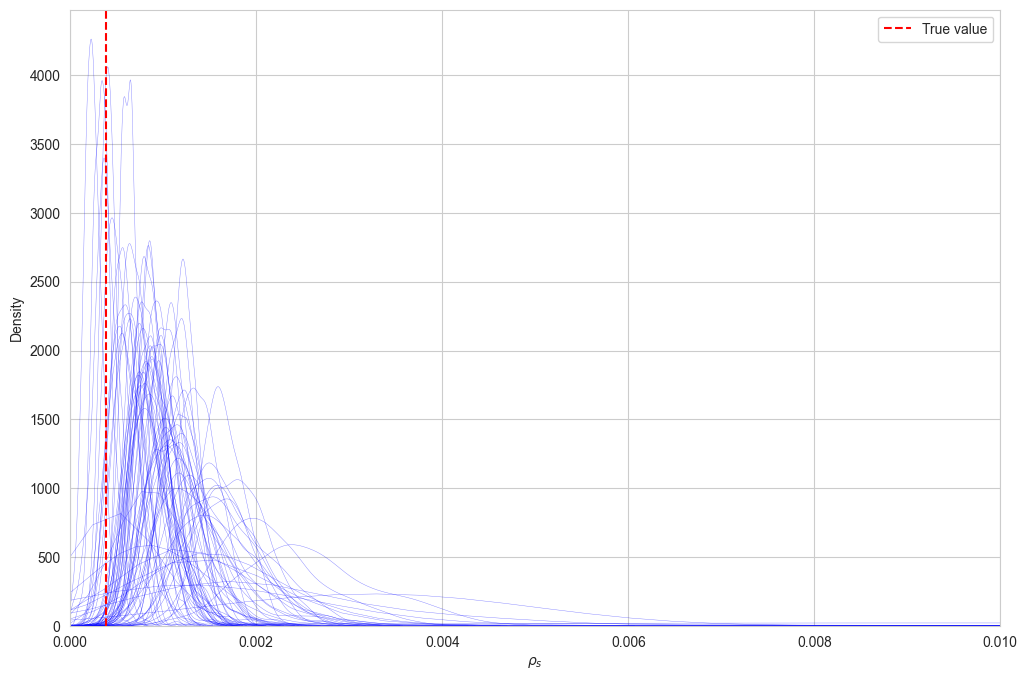

In [54]:
plt.figure(figsize=(12, 8))
sns.set_style('whitegrid')
for i in range(0, 100):
    sns.kdeplot(theta_post[i, :, 0], color='blue', linewidth=0.3, alpha=0.5)
plt.axvline(x=0.0003887292720131564, color='red', linestyle='dashed', label='True value')
plt.xlabel(r'$\rho_s$')
plt.xlim(0.0, 0.01)
plt.legend()
plt.show()